# LINEAR STRECH

In [4]:
import random
import numpy as np
import torch
import torch.nn.init as init
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data
import cv2
from skimage.transform import resize

In [15]:
# Set-up code:
im = data.coffee()
im = resize(im, (im.shape[0] // 8, im.shape[1] // 8), mode='reflect', preserve_range=True, anti_aliasing=True).astype(np.uint8)
im = np.swapaxes(np.swapaxes(im, 0, 2), 1, 2)
im = torch.from_numpy(im)

a = random.uniform(0,2)
b = random.uniform(-50,50)

In [ ]:
# im shape: (C, H, W)
print("im shape:", im.shape)

im shape: torch.Size([3, 50, 75])


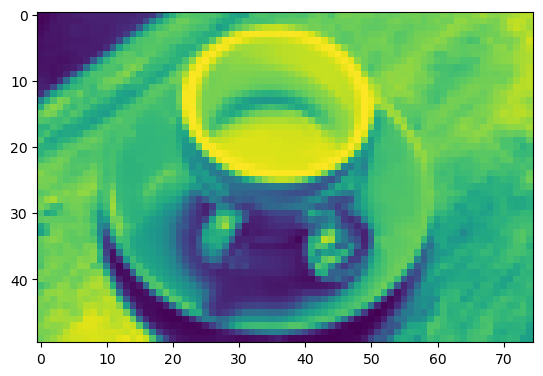

In [16]:
plt.imshow(im[0].numpy())

In [ ]:
# Prende come input un'immagine a colori "im" e due scalari "a" e "b" come input
# Applica una trasformazione pixel-wise lineare in cui ogni pixel "p" è trasformato in "a*p + b"
# Mette il risultato il "out"
image_float = im.to(torch.float32)
out = a * image_float + b

out = torch.round(out)
out = torch.clamp(out, min=0, max=255)
out = out.to(torch.uint8)

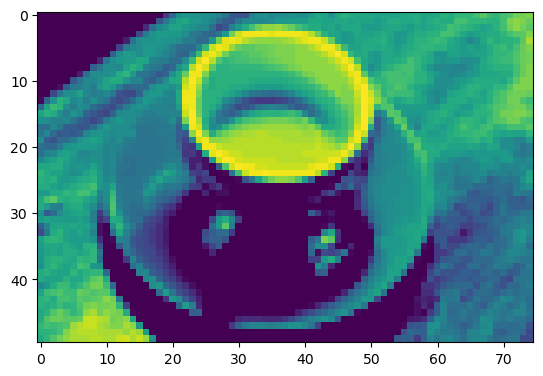

In [ ]:
# Output shape: (C, H, W)
plt.imshow(out[0].numpy())

# THRESHOLDING

In [20]:
import random
import numpy as np
from skimage import data
from skimage.transform import resize
import torch

im = data.camera()
im = resize(im, (im.shape[0] // 2, im.shape[1] // 2), mode='reflect', preserve_range=True, anti_aliasing=True).astype(np.uint8)
im = torch.from_numpy(im)
val = random.randint(0, 255)

In [21]:
# im shape: (C, H, W)
print("im shape:", im.shape)

im shape: torch.Size([256, 256])


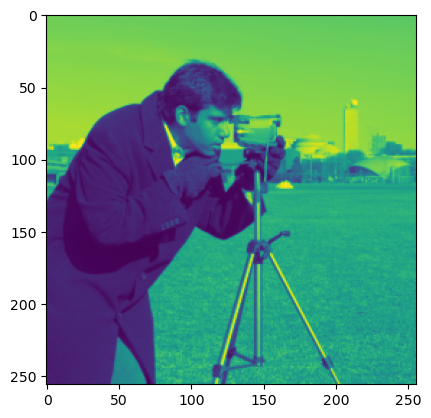

In [23]:
plt.imshow(im.numpy())

In [24]:
# Il codice prende un immagine di input in grayscale (1 solo canale!) con shape (H, W)
# Applica una threshold binaria sull'immagine al valore "val" e memorizza il risultato in out
# out: tutti i pixel maggiori della soglia saranno uguali a 255, tutti quelli minori saranno uguali a 0
out = (im > val)
out = out.to(torch.uint8)
out = out * 255

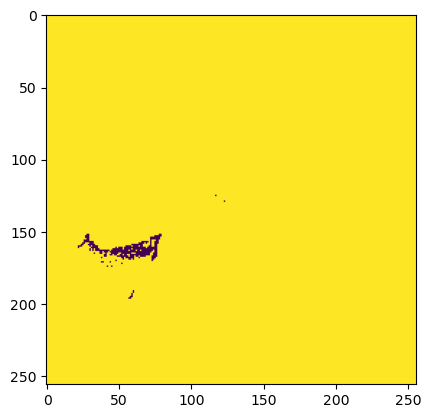

In [26]:
# Output shape: (H, W)
plt.imshow(out.numpy())

# OTSU THRESHOLDING

In [32]:
# Set-up code:
im = data.camera()
im = resize(im, (im.shape[0] // 2, im.shape[1] // 2), mode='reflect', preserve_range=True, anti_aliasing=True).astype(np.uint8)
im = torch.from_numpy(im)

In [33]:
# im shape: (C, H, W)
print("im shape:", im.shape)

im shape: torch.Size([256, 256])


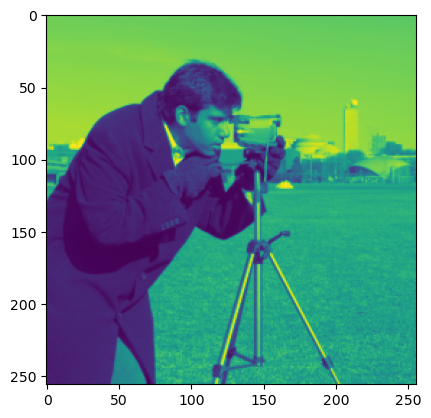

In [34]:
plt.imshow(im.numpy())

In [35]:
# OTSU THRESHOLD:

# numero di pixel 
# print = 65536 = 256*256
n = im.numel()

# istogramma H(i) -> 256 livelli (minlength)
# istogramma = frequenza per ogni valore di pixel da 0 a 255 -> bincount
# bincount -> 1D -> im.view(-1) da 2D ad 1D
im1d = im.view(-1)
H = torch.bincount(im1d, minlength=256).float()

# P(i) = H(i) / n, per ogni i
P = H/n

# livelli di grigio (ovvero da 0 a 255)
x = torch.arange(256, dtype=torch.float32)

# media e varianza per ogni classe
q1 = torch.cumsum(P, dim=0)
q2 = 1 - q1

# no divisioni per zero
nz = (q1 > 0) & (q2 > 0)

mu1 = torch.zeros_like(q1)
mu2 = torch.zeros_like(q2)
sigmaB = torch.zeros_like(q1)

# x*P è come fare i*P(i), per esempio 2*P(2) etc...
mu1[nz] = torch.cumsum(x*P, dim=0)[nz] / q1[nz]
mu2[nz] = (torch.sum(x * P) - torch.cumsum(x*P, dim=0)[nz]) / q2[nz]

sigmaB[nz] = q1[nz]*q2[nz]*(mu1[nz] - mu2[nz])**2

out = torch.argmax(sigmaB).item()

In [38]:
print("Otsu threshold:", out)

Otsu threshold: 102


# COLOR HISTOGRAM

In [39]:
# Set-up code:
im = data.astronaut()
im = np.swapaxes(np.swapaxes(im, 0, 2), 1, 2)
im = torch.from_numpy(im)
nbin = random.randint(32,128)

In [40]:
# im shape: (C, H, W)
print("im shape:", im.shape)

im shape: torch.Size([3, 512, 512])


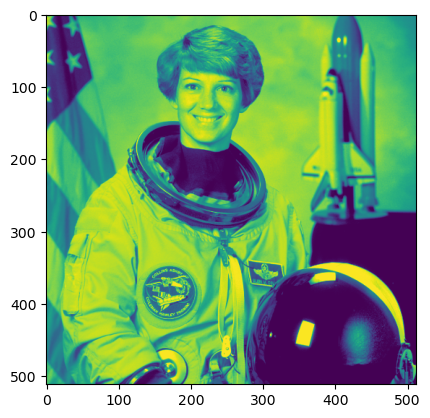

In [41]:
plt.imshow(im[0].numpy())

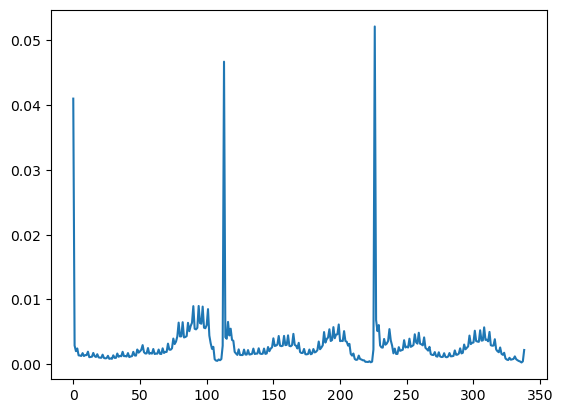

In [45]:
# Codice che prende in input un'immagine a colori e un intero "nbin"
# Calcola un histogramma (a colori) dell'immagine normalizzato e quantizzato con "nbin" su ogni canale
# L'output è un tensore con shape (3*nbin, ) contenente la concatenazione degli istogrammi su ogni canale
# L'output deve essere L1-Nomralizzato (somma finale dell'istogramma = 1)

# Quantizzazione (strategia): un pixel deve andare nel bin di indice "b" se e solo se "pixel*nbin // 256 == b"

H_list = []

for c in range(3):
    canale = im[c].flatten().to(torch.int64)
    bins = canale * nbin // 256
    hist = torch.bincount(bins, minlength=nbin).float()
    H_list.append(hist)

out = torch.cat(H_list)
out = out / out.sum()

plt.plot(out.numpy())
plt.show()